In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="darkgrid")
df = pd.read_csv("../data/clean_listings.csv")
print(df.shape)
df.head()

(466, 12)


,title,type,location,bedrooms,bathrooms,price_qar,area_sqm,district,city,segment,type_encoded,cluster
0,Modern 3 BHK APT | Fully Furnished | In Al Man...,Apartment,"Al Mansoura, Al Mansoura, Doha",3.0,3.0,7000,200.0,Al Mansoura,Doha,Budget,0,0
1,Bills Included | Luxury 1 Bedroom | No Commission,Apartment,"Lusail Residence, Marina District, Lusail",1.0,2.0,7569,86.0,Marina District,Lusail,Budget,0,0
2,LUXURY 2BR | MARINA VIEW | PORTO ARABIA | For ...,Apartment,"East Porto Drive, Porto Arabia, The Pearl Isla...",2.0,3.0,10000,175.0,The Pearl Island,Doha,Budget,0,0
3,LUSAIL NEW 1BHK FURNISHED SHORT TERM RENT NO FEE,Apartment,"Al Erkyah City, Lusail",1.0,2.0,5500,60.0,Al Erkyah City,Lusail,Budget,0,0
4,"LUSAIL 1BHK SHORT TERM OPTION BILLS INCL, POOL...",Apartment,"Al Erkyah City, Lusail",1.0,2.0,5500,60.0,Al Erkyah City,Lusail,Budget,0,0


In [2]:
# We can't feed text into a model "The Pearl Island" means nothing to math
# We use pd.get_dummies() to convert categories into 0/1 columns
# e.g. district_The Pearl Island = 1, all others = 0
# This is called "One-Hot Encoding"

df_model = pd.get_dummies(df, columns=["type", "district", "city"], drop_first=True)

# Define features (X) and target (y)
drop_cols = ["title", "location", "segment", "price_qar"]
X = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])
y = df_model["price_qar"]

# Drop any remaining nulls
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]}")

Features: 77
Samples:  466


In [3]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # use same scaler, don't refit!

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 372
Testing samples:  94


In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    r2  = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": round(mae), "R² Score": round(r2, 3)})
    print(f"{name}: MAE={round(mae)} QAR | R²={round(r2, 3)}")

results_df = pd.DataFrame(results)

Linear Regression: MAE=1765 QAR | R²=0.657
Ridge Regression: MAE=1755 QAR | R²=0.661


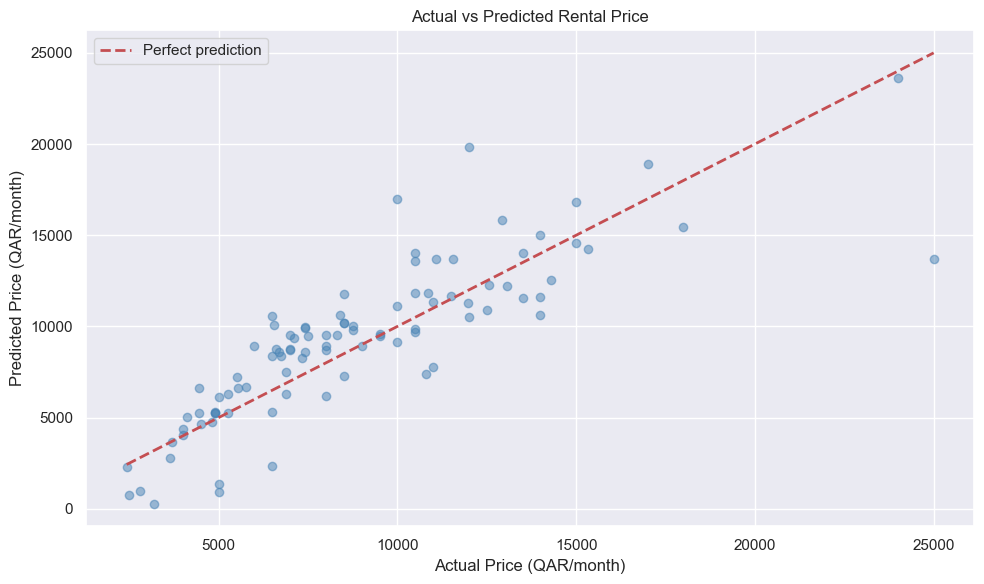

In [5]:
# Use Ridge predictions for the plot
best_model = Ridge(alpha=1.0)
best_model.fit(X_train_scaled, y_train)
preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds, alpha=0.5, color="steelblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=2, label="Perfect prediction")
plt.title("Actual vs Predicted Rental Price")
plt.xlabel("Actual Price (QAR/month)")
plt.ylabel("Predicted Price (QAR/month)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/regression_results.png")
plt.show()

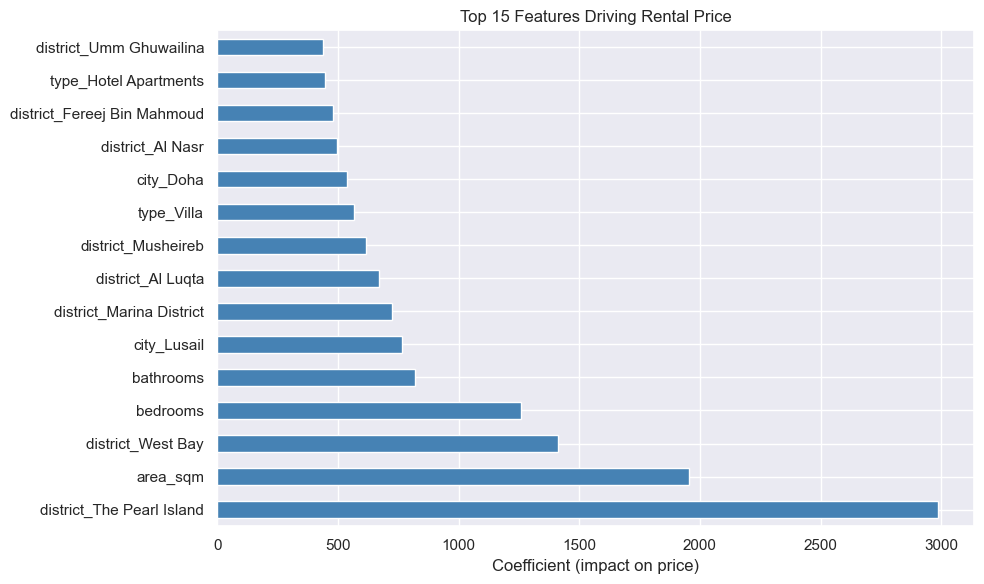

In [6]:
# Which features does the model rely on most?
coefficients = pd.Series(best_model.coef_, index=X.columns)
top_features = coefficients.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh", color="steelblue")
plt.title("Top 15 Features Driving Rental Price")
plt.xlabel("Coefficient (impact on price)")
plt.tight_layout()
plt.savefig("../data/feature_importance.png")
plt.show()